# Case Study 03: Cold Start Problems
It is very usual in industries where we launch new services or products that does not have any historical data to be accurately forecasted to see how would it perform in the market. In such situations, we resort to certain methodologies to forecast as accurately as possible.
* The delaphy method: where we bring different experts and aggregate their forecasting result
* customer commitments, Distribution assumptions, Scenario forecasting, Proxy products etc... 
In this case study we look at using M5 Walmart data as source, what are the features that we could use and what metrics that we should track in order to forecast 28 days ahead for the new product.

Our approach:
* choose only a couple of items that belong to different categories (FOODS,HOBBIES AND HOUSEHOLDS) to see what category are difficult to cold-start forecast.
    1. whether one model trained on whole store is enough or do we need to model by categories or departments too?
* Adding features gradually in order to track which feature addition gave us better forecast. We start with static features, calender feats and price features (which are known in advance)
* Analogous items: We pick few other items checking the cosine similarity to derive price momentum features, and set a baseline. We also check whether the number of items selected  has a impact on the forecasting
* forecast type: We keep the recursive lightGBM framework we have developed so far and use foracasting horizon =28 days ahead. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# Adds the root_dir (parent of notebooks/) to sys.path
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"data"


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.metrics.pairwise import cosine_similarity
from src.features import get_calendar_features 


In [4]:
# load the data 
known_data = pd.read_parquet(DATA_DIR/'processed/sales_known_ca_1.parquet')
price_df = pd.read_csv(DATA_DIR/"raw/sell_prices.csv")
calendar_df = pd.read_csv(DATA_DIR/"raw/calendar.csv")


cal_feats = get_calendar_features(calendar_df)
# cal_feats

# cal_feats[cal_feats['is_religious_event']==1]
cols_to_drop = cal_feats.columns

df = known_data.copy()
df = df.drop(columns=[col for col in df.columns if col in cols_to_drop if col != 'date'])
df = df.merge(cal_feats,on='date',how='left')
df = df.drop(columns=['event_name_1','event_name_2','event_type_1','event_type_2','weekday'])
# df.head()

In [5]:
# ---------------------------------------------------------------
# 1. Launch date detection — sell_prices first appearance, not first sale
# ---------------------------------------------------------------
def get_item_launch_dates(price_df:pd.DataFrame, calendar_df:pd.DataFrame,store_id:str='CA_1'):
    """price_df: item_id, wm_yr_wk, sell_price 
    Returns item_id -> first calendar date the item had a price (i.e. was sellable)."""
    price_df = price_df[price_df['store_id']==store_id].copy()

    first_week = price_df.groupby('item_id', observed=True)['wm_yr_wk'].min().reset_index()
    first_week.columns = ['item_id', 'wm_yr_wk']
    # map wm_yr_wk -> earliest date in that week
    week_start = calendar_df.groupby('wm_yr_wk')['date'].min().reset_index()
    launch = first_week.merge(week_start, on='wm_yr_wk', how='left')
    launch['date'] = pd.to_datetime(launch['date'])
    return launch.rename(columns={'date': 'launch_date'})[['item_id', 'launch_date']]

# ---------------------------------------------------------------
# 2. Candidate cold-start items: launched late enough to have real
#    post-launch data 
# ---------------------------------------------------------------
def select_case_study_items(sales_df:pd.DataFrame, launch_df:pd.DataFrame, min_post_launch_days:int=28, per_category:int=2, seed:int=42):
    max_date = sales_df['date'].max()
    dataset_start = sales_df['date'].min()

    candidates = launch_df[
        (launch_df['launch_date'] > dataset_start + pd.Timedelta(days=180)) & 
        (launch_df['launch_date'] <= max_date - pd.Timedelta(days=min_post_launch_days))
    ].copy()

    meta = sales_df[['item_id', 'cat_id', 'dept_id']].drop_duplicates('item_id')
    candidates = candidates.merge(meta, on='item_id', how='left')

    picked = (candidates.groupby('cat_id', observed=True)
              .apply(lambda g: g.sample(min(per_category, len(g)), random_state=seed),include_groups=True)
              .reset_index(drop=True))
    return picked

# ---------------------------------------------------------------
# 3. Static-feature similarity — zero-day-available info only
# ---------------------------------------------------------------
def build_item_feature_matrix(sales_df:pd.DataFrame, launch_df:pd.DataFrame):
    """One row per item: dept_id one-hot + launch-week price z-scored within dept.
    Uses only static/catalog attributes — no sales history."""
    meta = sales_df[['item_id', 'dept_id', 'cat_id']].drop_duplicates('item_id')

    launch_price = (sales_df.query('date == launch_date')
                     .groupby('item_id', observed=True)['sell_price'].first()
                     .reset_index())

    feat = meta.merge(launch_price, on='item_id', how='left')
    feat['price_z'] = feat.groupby('dept_id', observed=True)['sell_price'] \
                           .transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))

    dept_dummies = pd.get_dummies(feat['dept_id'], prefix='dept')
    X = pd.concat([dept_dummies, feat[['price_z']]], axis=1).fillna(0)
    X.index = feat['item_id']
    return X  # DataFrame: item_id index -> feature vector

# ---------------------------------------------------------------
# 4. Find k nearest neighbors for a target item (excluding itself
#    and other cold-start-candidate items — neighbors must be mature)
# ---------------------------------------------------------------
def find_similar_items(target_item:str, feature_matrix:pd.DataFrame, exclude_ids:str, k:int=20):
    target_vec = feature_matrix.loc[[target_item]].values
    pool = feature_matrix.drop(index=[i for i in exclude_ids if i in feature_matrix.index])
    sims = cosine_similarity(target_vec, pool.values)[0]
    ranked = pd.Series(sims, index=pool.index).sort_values(ascending=False)
    return ranked.head(k)  # Series: item_id -> similarity score



def build_cold_start_feats(df:pd.DataFrame):
    ''' build cold start feats for given df, must contain launch_date
    '''

    assert 'launch_date' in df.columns, 'AssertionError: col launch_date not found'

    df = df.copy()

    df['sell_price'] = df['sell_price'].astype('float32')
    # create days from launch 
    df['days_since_launch'] = (df['date']-df['launch_date']).dt.days + 1 

    # Filter to first month (28 days)
    df = df[df['days_since_launch'].between(1, 28)]
  
    # Department level stats
    df['cat_median_on_launch_day_t'] = df.groupby(['cat_id', 'days_since_launch'],observed=True)['sales'].transform('median')
    df['cat_mean_on_launch_day_t'] = df.groupby(['cat_id', 'days_since_launch'],observed=True)['sales'].transform('mean')
    df['cat_std_on_launch_day_t'] = df.groupby(['cat_id', 'days_since_launch'],observed=True)['sales'].transform('std') 

    df['dept_median_on_launch_day_t'] = df.groupby(['dept_id', 'days_since_launch'],observed=True)['sales'].transform('median')
    df['dept_mean_on_launch_day_t'] = df.groupby(['dept_id', 'days_since_launch'],observed=True)['sales'].transform('mean')
    df['dept_std_on_launch_day_t'] = df.groupby(['dept_id', 'days_since_launch'],observed=True)['sales'].transform('std') 

    # Price z-score
    df['price_z_on_launch_day_t'] = df.groupby(['dept_id','cat_id','days_since_launch'], observed=True)['sell_price'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )


    agg_feats = ['cat_median_on_launch_day_t','cat_mean_on_launch_day_t','cat_std_on_launch_day_t','dept_median_on_launch_day_t',
                         'dept_mean_on_launch_day_t','dept_std_on_launch_day_t','price_z_on_launch_day_t']
    
    return df, agg_feats

# ---------------------------------------------------------------
# 5 . train a global model
# ---------------------------------------------------------------

def train_item_agnostic_models(df: pd.DataFrame,
                                          feature_cols: list = None,
                                          cat_cols: list = ('dept_id', 'cat_id'))->tuple[dict,dict]:
    """Trains point + q10/q90 LightGBM on whole mature items given in df (their own real sales during
    their first 28 days). item_id is deliberately excluded -- the model must generalize to
    the target cold-start item, which has no item_id it has ever seen.
    Training rows = neighbors' actual (dept/calendar/price/analog-prior) -> their own real sales.
    """
    import lightgbm as lgb

    df = df.copy()

    cat_categories = {}
    for col in cat_cols:
        df[col] = df[col].astype('category')
        cat_categories[col] = df[col].cat.categories

    X = df[feature_cols]
    y = df['sales']

    models = {}
    models['point'] = lgb.LGBMRegressor(objective='tweedie', n_estimators=200,
                                         verbose=-1).fit(X, y, categorical_feature=list(cat_cols))
    models['q10'] = lgb.LGBMRegressor(objective='quantile', alpha=0.10, n_estimators=200,
                                       verbose=-1).fit(X, y, categorical_feature=list(cat_cols))
    models['q90'] = lgb.LGBMRegressor(objective='quantile', alpha=0.90, n_estimators=200,
                                       verbose=-1).fit(X, y, categorical_feature=list(cat_cols))
    models['q95'] = lgb.LGBMRegressor(objective='quantile', alpha=0.95, n_estimators=200,
                                       verbose=-1).fit(X, y, categorical_feature=list(cat_cols))
    models['q97'] = lgb.LGBMRegressor(objective='quantile', alpha=0.97, n_estimators=200,
                                       verbose=-1).fit(X, y, categorical_feature=list(cat_cols))

    return models, cat_categories



def predict_cold_start(target_df: pd.DataFrame, models: dict,  feature_cols: list, categorical_cols: dict, horizon: int = 28) -> pd.DataFrame:
    # target_static_df: contains static (calender+ item  ids) and dynamic (coldstart feat on each day since launch aggregated from nbrs)
    # 1. Group neighbors' features by day_since_launch (d_1 to d_28) 
    # to form a single 28-row input vector for the target item
    # 1. Select numeric feature columns (exclude categorical metadata)
    
    
    # Ensure categorical types match training
    for col, cats in categorical_cols.items():
        if col in target_df.columns:
            target_df[col] = pd.Categorical(target_df[col], categories=cats)
        else:
            # Inject target's categorical values if not present in features
            target_df[col] = pd.Categorical([target_df[col]] * horizon, categories=cats)


    # 2. Predict point and quantile forecasts (length = horizon)
    X_target = target_df[feature_cols]
    point = np.maximum(models['point'].predict(X_target), 0)
    q10 = np.maximum(models['q10'].predict(X_target), 0)
    q90 = np.maximum(models['q90'].predict(X_target), 0)
    q95 = np.maximum(models['q95'].predict(X_target), 0)
    q97 = np.maximum(models['q97'].predict(X_target), 0)

    # 3. Construct prediction DataFrame
    preds = pd.DataFrame({
        'item_id': target_df['item_id'],
        'date': target_df['date'],
        'sales_pred': point,
        'q10': np.minimum(q10, point),
        'q90': np.maximum(q90, point),
        'q95' : np.maximum(q95,point),
        'q97' : np.maximum(q97,point)
    })
    return preds
# 6. Naive baseline for FVA: dept-average of ALL mature items
#    (not similarity-selected) over the same dates — the floor to beat


def build_dept_baseline(
    target_item: str, 
    target_dept: str, 
    launch_date: pd.Timestamp,
    sales_mature: pd.DataFrame, 
    horizon: int = 28, 
    stat: str = 'mean'  # Default to 'mean' for zero-inflated demand
) -> pd.DataFrame:
    """Calculates true department baseline trajectory using all mature items."""
    
    forecast_dates = pd.date_range(launch_date, periods=horizon, freq='D')

    # Filter sales_mature for target department within first 28 launch days
    dept_df = sales_mature[
        (sales_mature['dept_id'] == target_dept) & 
        (sales_mature['days_since_launch'].between(1, horizon))
    ].copy()

    # Aggregate across ALL items in the department per launch day
    if stat == 'mean':
        baseline_curve = dept_df.groupby('days_since_launch')['sales'].mean().reset_index()
    else:
        baseline_curve = dept_df.groupby('days_since_launch')['sales'].median().reset_index()

    baseline_curve.rename(columns={'sales': 'sales_pred'}, inplace=True)

    # Standard deviation across department items per day for intervals
    std_curve = dept_df.groupby('days_since_launch')['sales'].std().values

    from scipy.stats import norm

    def gaussian_quantile(sales_pred, std_curve, target_q):
        z = norm.ppf(target_q)
        return (sales_pred + z * std_curve).clip(lower=0)

    baseline_curve['q95'] = gaussian_quantile(baseline_curve['sales_pred'], std_curve, 0.95)
    baseline_curve['q97'] = gaussian_quantile(baseline_curve['sales_pred'], std_curve, 0.97)
    baseline_curve['q10'] = gaussian_quantile(baseline_curve['sales_pred'],std_curve, 0.10)
    baseline_curve['q90'] = gaussian_quantile(baseline_curve['sales_pred'],std_curve, .90)
    baseline_curve['item_id'] = target_item
    baseline_curve['date'] = forecast_dates[:len(baseline_curve)]

    return baseline_curve[['item_id', 'date', 'days_since_launch', 'sales_pred', 'q10', 'q90','q95','q97']]

In [6]:
def get_scalar(val) -> float:
    """
    Safely converts Pandas Series/DataFrames/Arrays into a single scalar float.
    """
    if isinstance(val, (pd.Series, pd.DataFrame)):
        # If it's a DataFrame with specific column or single value
        if isinstance(val, pd.DataFrame):
            return float(val.iloc[0, -1])
        return float(val.iloc[0])
    return float(val)

In [7]:
sales_df = df.copy()
launch_df = get_item_launch_dates(price_df, calendar_df)
case_items = select_case_study_items(sales_df, launch_df, min_post_launch_days=100, per_category=2)
# case_items

/tmp/ipykernel_4755/3109055377.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(per_category, len(g)), random_state=seed),include_groups=True)


In [8]:
# merge launch df with sales_df 
sales_df = sales_df.merge(launch_df,on=['item_id'],how='left')
sales_df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'sales',
       'date', 'sell_price', 'wm_yr_wk', 'wday', 'month', 'year', 'd',
       'snap_CA', 'snap_TX', 'snap_WI', 'day_of_week', 'day_of_month',
       'week_of_year', 'is_event', 'days_to_next_event',
       'days_since_last_event', 'is_event_in_7_days', 'is_sporting_event',
       'is_cultural_event', 'is_national_event', 'is_religious_event',
       'launch_date'],
      dtype='object')

In [9]:
from src.metrics import calculate_wape,bias 
from src.pipeline import cost_per_item
from src.metrics import forecast_error


def cold_start_preds(feature_cols:list,cat_cols:list,static_feats:list):

    # neighbors = find_similar_items()
    all_preds_list = []
    all_metrics_list = []
    all_feat_importances_list = []
    for _, row in case_items.iterrows():

        target, launch_date, cat_id, dept_id = row['item_id'], row['launch_date'],row['cat_id'],row['dept_id']
        
        item_actuals = sales_df[sales_df['item_id'] == target].copy()
        item_actuals = (item_actuals[item_actuals['date'].between(launch_date, launch_date + pd.Timedelta(days=27))].sort_values('date').reset_index(drop=True))
        item_actuals['days_since_launch'] = (item_actuals['date']-item_actuals['launch_date']).dt.days + 1

        # find the mature items that are launched before and have atleast 28 days and does not cross target launch date
        cutoff = launch_date - pd.Timedelta(days=28) # one month before launch date
        mask  = sales_df['launch_date'] + pd.Timedelta(days=60) <= cutoff 

        sales_mature = sales_df[mask].copy()

        # build the cold features 
        sales_mature, launch_day_feats = build_cold_start_feats(sales_mature)

        item_row = sales_df[sales_df['item_id']==target] 

        sales_mature_temp = pd.concat((sales_mature,item_row)).reset_index()
        feature_matrix = build_item_feature_matrix(sales_mature_temp,launch_df)
        # train the models 
        models_ ,  cat_categories = train_item_agnostic_models(sales_mature,feature_cols=feature_cols,cat_cols= cat_cols)
  
        # find neighbours for the target item 

        nbrs  = find_similar_items(target_item = target,feature_matrix=feature_matrix,exclude_ids= case_items['item_id'].tolist(),k=30)
        
        # 4. Extract neighbor records (which ALREADY have globally-computed Z-scores)
        feats_nbrs = sales_mature[sales_mature['item_id'].isin(nbrs.index)].copy()
        feats_nbrs = feats_nbrs[feats_nbrs['days_since_launch'].between(1, 28)]

        # aggregate by launch day feats to get 28 rows for each neighbor , we can also use weighted average
        agg_feats_nbrs = feats_nbrs.groupby('days_since_launch')[launch_day_feats].mean().reset_index()
        
        item_static = item_actuals[static_feats].copy()
        # merge this with agg_feats_nbrs 
        item_feats = item_static.merge(agg_feats_nbrs,on='days_since_launch',how='left') # this is the test set, give this to predict
        # predict 
   
        pred_ml = predict_cold_start(target_df=item_feats,models=models_,feature_cols=feature_cols,categorical_cols=cat_categories,horizon=28)
      
        
        pred_nbrs = build_dept_baseline(target,target_dept=dept_id,launch_date=launch_date,sales_mature=feats_nbrs)
        pred_baseline = build_dept_baseline(target, target_dept=dept_id, launch_date=launch_date, sales_mature=sales_mature)
        # merge this with actual sales of the target item

        # =========================================================================
        # ACCUMULATE PREDICTIONS INTO MASTER PREDICTION DATAFRAME
        # =========================================================================
        df_item_preds = item_actuals[["item_id", "date", "days_since_launch", "sales"]].copy()
        df_item_preds["pred_lgb"] = pred_ml["sales_pred"].values
        df_item_preds["pred_base_nbr"] = pred_nbrs["sales_pred"].values
        df_item_preds["pred_base"] = pred_baseline["sales_pred"].values
        df_item_preds['pred_lgb_q10'] = pred_ml['q10'].values
        df_item_preds['pred_lgb_q90'] = pred_ml['q90'].values 
        df_item_preds['pred_base_q10'] = pred_baseline['q10'].values 
        df_item_preds['pred_base_q90'] = pred_baseline['q90'].values 
        df_item_preds['pred_base_nbr_q10'] = pred_nbrs['q10'].values 
        df_item_preds['pred_base_nbr_q90'] = pred_nbrs['q90'].values 
        df_item_preds['pred_lgb_q95'] = pred_ml['q95'].values
        df_item_preds['pred_lgb_q97'] = pred_ml['q97'].values
        df_item_preds['pred_base_nbr_q95'] = pred_nbrs['q95'].values 
        df_item_preds['pred_base_nbr_q97'] = pred_nbrs['q97'].values 
        df_item_preds['pred_base_q95'] = pred_baseline['q95'].values 
        df_item_preds['pred_base_q97'] = pred_baseline['q97'].values 

        all_preds_list.append(df_item_preds)

        # 1. BIAS (%)
        bias_base = bias(item_actuals['sales'], pred_baseline['sales_pred'])
        bias_nbr = bias(item_actuals['sales'], pred_nbrs['sales_pred'])
        bias_ml = bias(item_actuals['sales'], pred_ml['sales_pred'])

        # 2. Total Holding Cost (Extract scalar values explicitly) 90 the level
        cost_base = get_scalar(cost_per_item(item_actuals, pred_baseline))
        cost_nbr = get_scalar(cost_per_item(item_actuals, pred_nbrs))
        cost_ml = get_scalar(cost_per_item(item_actuals, pred_ml))

        # 95 the percentile
        cost_base_95 = get_scalar(cost_per_item(item_actuals, pred_baseline,safety_level='q95'))
        cost_nbr_95 = get_scalar(cost_per_item(item_actuals, pred_nbrs,safety_level='q95'))
        cost_ml_95 = get_scalar(cost_per_item(item_actuals, pred_ml,safety_level='q95'))
        # 97 the level
        cost_base_97 = get_scalar(cost_per_item(item_actuals, pred_baseline,safety_level='q97'))
        cost_nbr_97 = get_scalar(cost_per_item(item_actuals, pred_nbrs,safety_level='q97'))
        cost_ml_97 = get_scalar(cost_per_item(item_actuals, pred_ml,safety_level='q97'))

        # 3. MAE / WAPE (%) (Extract scalar values explicitly)
        mae_base = get_scalar(forecast_error(item_actuals, pred_baseline))
        mae_nbr = get_scalar(forecast_error(item_actuals, pred_nbrs))
        mae_ml = get_scalar(forecast_error(item_actuals, pred_ml))

        result_df = pd.DataFrame(
                    {
                        "item_id": target,
                        "model": ["Global_Dept_baseline", "Nbr_Dept_baseline", "lgb"],
                        "bias_pct": [bias_base, bias_nbr, bias_ml],
                        "cost_90": [cost_base, cost_nbr, cost_ml],
                        "cost_95": [cost_base_95, cost_nbr_95, cost_ml_95],
                        "cost_97": [cost_base_97, cost_nbr_97, cost_ml_97],
                        "mae": [mae_base, mae_nbr, mae_ml],
                    }
                )

        all_metrics_list.append(result_df)

        lgb_model = models_['point']
        df_importance = pd.DataFrame(
            {
                "item_id": target,
                "feature": feature_cols,
                "importance": lgb_model.feature_importances_,
            }
        )

        all_feat_importances_list.append(df_importance)

        print(f"======= Metric for {target} =======")

        print(result_df.round(2).to_string())

    df_all_preds = pd.concat(all_preds_list, ignore_index=True)
    df_all_metrics = pd.concat(all_metrics_list, ignore_index=True)
    df_feat_imp = pd.concat(all_feat_importances_list,ignore_index=True)
    return df_all_preds, df_all_metrics, df_feat_imp


In [10]:

static_feats =  ['item_id','date','dept_id', 'cat_id', 'sell_price', 'wm_yr_wk', 'wday', 'month', 'year', 'snap_CA', 'day_of_week', 'day_of_month', 
                'week_of_year', 'is_event', 'days_to_next_event', 'days_since_last_event', 'is_event_in_7_days', 'is_sporting_event',
                'is_cultural_event', 'is_national_event', 'is_religious_event','launch_date','days_since_launch']

feat_set_1  = ['dept_id', 'cat_id', 'sell_price', 'wm_yr_wk', 'wday', 'month', 'year', 'snap_CA', 'day_of_week', 'day_of_month', 
                'week_of_year', 'is_event', 'days_to_next_event', 'days_since_last_event', 'is_event_in_7_days', 'is_sporting_event',
                'is_cultural_event', 'is_national_event', 'is_religious_event']

feat_set_2 = feat_set_1 + ['cat_median_on_launch_day_t','cat_mean_on_launch_day_t','cat_std_on_launch_day_t','dept_median_on_launch_day_t',
                         'dept_mean_on_launch_day_t','dept_std_on_launch_day_t','price_z_on_launch_day_t']



In [11]:
# result_1 = cold_start_preds(feature_cols=feat_set_1,cat_cols=['dept_id','cat_id'],static_feats=static_feats)


In [12]:
preds, metrics, imp_feats = cold_start_preds(feature_cols=feat_set_2,cat_cols=['dept_id','cat_id'],static_feats=static_feats)

======= Metric for FOODS_1_200 =======
       item_id                 model  bias_pct  cost_90  cost_95  cost_97   mae
0  FOODS_1_200  Global_Dept_baseline     -0.62     7.80     4.77     3.10  3.76
1  FOODS_1_200     Nbr_Dept_baseline     -0.24     0.73     0.12     0.11  2.99
2  FOODS_1_200                   lgb     -0.30     0.87     0.06     0.06  2.97
======= Metric for FOODS_2_234 =======
       item_id                 model  bias_pct  cost_90  cost_95  cost_97   mae
0  FOODS_2_234  Global_Dept_baseline      2.15     0.21     0.26     0.29  2.28
1  FOODS_2_234     Nbr_Dept_baseline      3.22     0.19     0.22     0.24  2.87
2  FOODS_2_234                   lgb      0.15     1.49     0.20     1.71  1.77
======= Metric for HOBBIES_1_062 =======
         item_id                 model  bias_pct  cost_90  cost_95  cost_97   mae
0  HOBBIES_1_062  Global_Dept_baseline      8.00     0.08     0.10     0.11  1.63
1  HOBBIES_1_062     Nbr_Dept_baseline     14.77     0.11     0.13     0.14  

In [13]:
metrics

,item_id,model,bias_pct,cost_90,cost_95,cost_97,mae
0,FOODS_1_200,Global_Dept_baseline,-0.624454,7.802648,4.770229,3.098624,3.756123
1,FOODS_1_200,Nbr_Dept_baseline,-0.238624,0.732151,0.121487,0.107094,2.993233
2,FOODS_1_200,lgb,-0.297484,0.869725,0.060368,0.063546,2.974312
3,FOODS_2_234,Global_Dept_baseline,2.145763,0.212236,0.258531,0.288597,2.275377
4,FOODS_2_234,Nbr_Dept_baseline,3.218333,0.188485,0.221126,0.242324,2.870616
5,FOODS_2_234,lgb,0.152915,1.486045,0.203356,1.705078,1.772941
6,HOBBIES_1_062,Global_Dept_baseline,7.996450,0.083125,0.102171,0.114541,1.631015
7,HOBBIES_1_062,Nbr_Dept_baseline,14.766667,0.106518,0.128371,0.142562,3.044035
8,HOBBIES_1_062,lgb,0.351001,0.418742,0.169120,0.064090,0.624356
9,HOBBIES_1_250,Global_Dept_baseline,29.077093,0.516365,0.629699,0.703302,2.157584


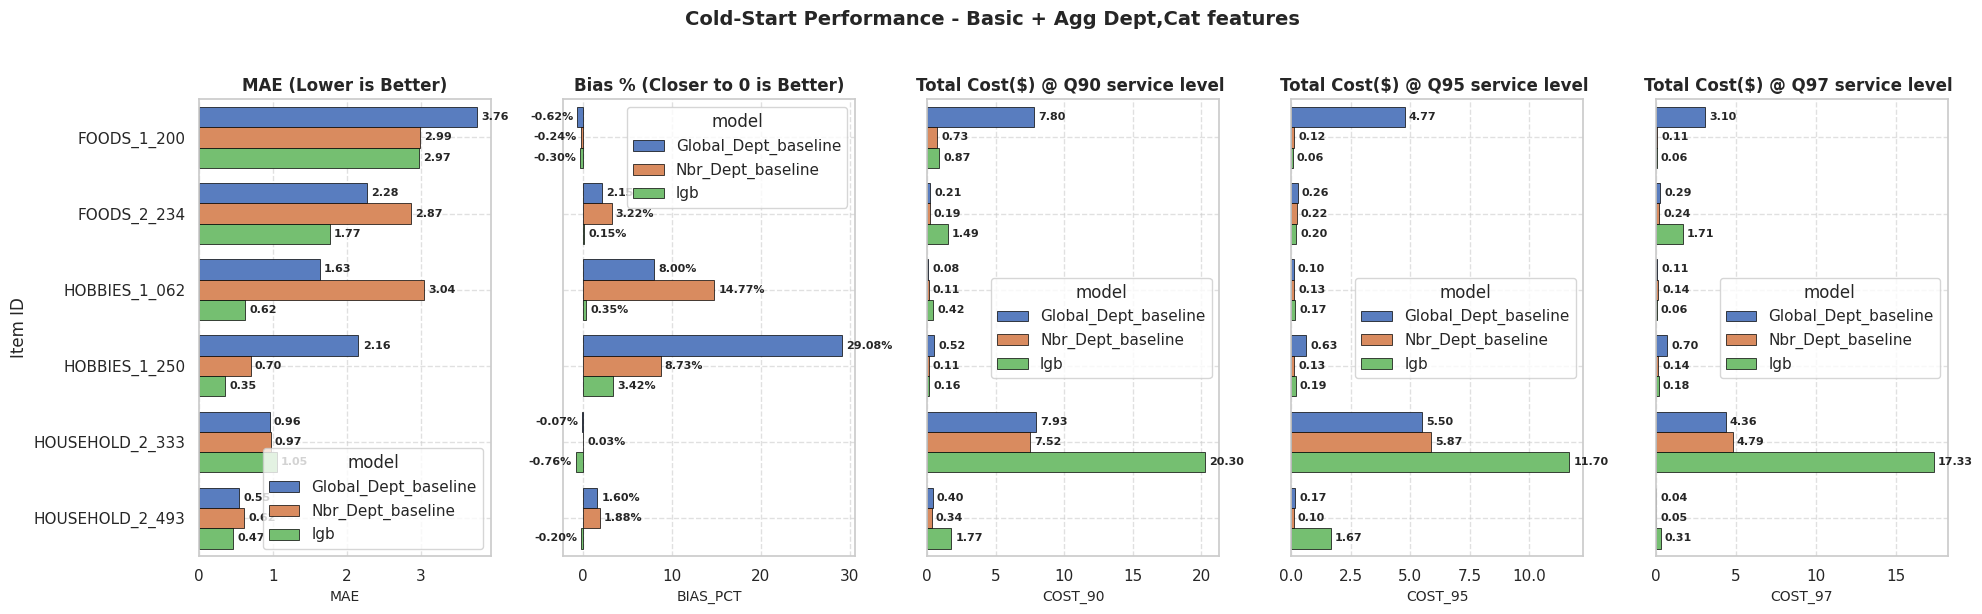

In [22]:
"""
Cold-Start Evaluation Metrics Visualizer with Bar Labels
Author: Coding Partner
Goal: Render annotated bar plots with explicit metric values displayed on each bar.
"""

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set a clean aesthetic grid style
sns.set_theme(style="whitegrid", palette="muted")


def plot_cold_start_metrics(
    metrics_dict: pd.DataFrame, title_prefix: str = ""
):
    """Generates comparative bar plots for MAE, Bias %, and Total Cost

    with exact numeric value labels annotated directly on each bar.

    Parameters:
    -----------
    metrics_dict : dict[str, pd.DataFrame]
        Dictionary where keys are item IDs (e.g. 'FOODS_1_200') and values
        are DataFrames indexed by method ('base', 'base_nbr', 'lgb') with
        columns ['bias_pct', 'total_cost', 'mae'].
    title_prefix : str, optional
        A custom prefix string (e.g. 'Basic Features' or 'Derived Neighbor Features')
        to display in the overall figure title.

    Returns:
    --------
    None (displays matplotlib plot window)
    """

    # 2. Setup 1x3 subplots figure
    fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

    if title_prefix:
        fig.suptitle(
            f"Cold-Start Performance - {title_prefix}",
            fontsize=14,
            fontweight="bold",
            y=1.02,
        )

    # Metric column mappings and panel titles
    metrics_config = [
        ("mae", "MAE (Lower is Better)", "{:.2f}"),
        ("bias_pct", "Bias % (Closer to 0 is Better)", "{:.2f}%"),
        ("cost_90", "Total Cost($) @ Q90 service level ", "{:.2f}"),
        ("cost_95", "Total Cost($) @ Q95 service level ", "{:.2f}"),
        ("cost_97", "Total Cost($) @ Q97 service level ", "{:.2f}"),
    ]

    # 3. Plot each metric and add numeric bar labels
    for ax, (metric_col, title, fmt) in zip(axes, metrics_config):
        barplot = sns.barplot(
            data=metrics,
            y="item_id",
            x=metric_col,
            hue="model",
            ax=ax,
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel(metric_col.upper(), fontsize=10)
        ax.set_ylabel("Item ID" if ax == axes[0] else "")
        ax.grid(True, linestyle="--", alpha=0.6)

        # Annotate exact numeric values on each bar
        for container in ax.containers:
            ax.bar_label(
                container,
                fmt=fmt,
                padding=3,
                fontsize=8,
                fontweight="bold",
            )

    plt.tight_layout()
    plt.show()

plot_cold_start_metrics(metrics_dict=metrics,title_prefix='Basic + Agg Dept,Cat features')

In [15]:
# `import pandas as pd
import numpy as np

def empirical_quantile_coverage(df, models, sales_col='sales', target_q10=0.10, target_q90=0.90):
    """
    df: one row per item_id/date, with columns pred_{model}_q10, pred_{model}_q90 for each model in `models`
    models: list of model name strings, e.g. ['lgb', 'base', 'base_nbr']
    target_q10/target_q90: the nominal quantile levels the models were meant to hit

    Returns one row per item_id per model with breach rates and interval coverage.
    """
    results = []

    for model in models:
        q10_col = f'pred_{model}_q10'
        q90_col = f'pred_{model}_q90'
        q95_col = f'pred_{model}_q95'
        q97_col = f'pred_{model}_q97'

        for item_id, g in df.groupby('item_id'):
            n = len(g)
            sales = g[sales_col].values
            q10 = g[q10_col].values
            q90 = g[q90_col].values
            q95 = g[q95_col].values
            q97 = g[q97_col].values
            
            below_q10 = (sales < q10).sum()          # should happen ~10% of the time
            above_q90 = (sales > q90).sum()           # should happen ~10% of the time
            above_q95 = (sales>q95).sum()
            above_q97 = (sales>q97).sum()

            inside_interval = ((sales >= q10) & (sales <= q90)).sum()  # should happen ~80% of the time
            inside_interval_q95 = ((sales >= q10) & (sales <= q95)).sum()  # should happen ~80% of the time
            inside_interval_q97 = ((sales >= q10) & (sales <= q97)).sum()  # should happen ~80% of the time

            results.append({
                'item_id': item_id,
                'model': model,
                'n_days': n,
                'pct_below_q10': below_q10 / n,
                'pct_above_q90': above_q90 / n,       # <-- the number you actually want
                'pct_above_q95': above_q95 / n,
                'pct_above_q97': above_q97 / n,
                'pct_inside_interval': inside_interval / n,
                'pct_inside_interval_q95': inside_interval_q95 / n,
                'pct_inside_interval_q97': inside_interval_q97 / n,
                'target_below_q10': target_q10,
                'target_above_q90': 1 - target_q90,
                'target_inside': target_q90 - target_q10,
            })

    return pd.DataFrame(results)

coverage = empirical_quantile_coverage(preds, models=['lgb', 'base', 'base_nbr'])
coverage.sort_values(['item_id', 'model'])

,item_id,model,n_days,pct_below_q10,pct_above_q90,pct_above_q95,pct_above_q97,pct_inside_interval,pct_inside_interval_q95,pct_inside_interval_q97,target_below_q10,target_above_q90,target_inside
6,FOODS_1_200,base,28,0.0,0.357143,0.250000,0.250000,0.642857,0.750000,0.750000,0.1,0.1,0.8
12,FOODS_1_200,base_nbr,28,0.0,0.071429,0.035714,0.000000,0.928571,0.964286,1.000000,0.1,0.1,0.8
0,FOODS_1_200,lgb,28,0.0,0.107143,0.000000,0.000000,0.892857,1.000000,1.000000,0.1,0.1,0.8
7,FOODS_2_234,base,28,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.1,0.1,0.8
13,FOODS_2_234,base_nbr,28,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.1,0.1,0.8
1,FOODS_2_234,lgb,28,0.0,0.071429,0.000000,0.035714,0.928571,1.000000,0.964286,0.1,0.1,0.8
8,HOBBIES_1_062,base,28,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.1,0.1,0.8
14,HOBBIES_1_062,base_nbr,28,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.1,0.1,0.8
2,HOBBIES_1_062,lgb,28,0.0,0.035714,0.035714,0.000000,0.964286,0.964286,1.000000,0.1,0.1,0.8
9,HOBBIES_1_250,base,28,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.1,0.1,0.8


In [16]:
"""
Cold-Start Visualizer
Goal: Plot actual sales vs model predictions directly from the df_all_preds master DataFrame.
"""

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_actual_vs_preds(
    df_all_preds: pd.DataFrame, item_id: str = None, figsize: tuple = (12, 5),filename:str=BASE_DIR/'case_studies/cold_start_preds.png'
):
    """Plots daily actual sales vs. predictions (LGB, Baseline Neighbor, Baseline)

    from the consolidated master predictions DataFrame.

    Parameters:
    -----------
    df_all_preds : pd.DataFrame
        Master DataFrame containing columns:
        ['item_id', 'date', 'days_since_launch', 'sales', 'pred_lgb',
        'pred_base_nbr', 'pred_base']
    item_id : str, optional
        Specific item ID to plot. If None, plots all unique items in separate figures.
    figsize : tuple, default=(12, 5)
        Figure size dimensions (width, height).
    """
    # 1. Determine items to plot
    items_to_plot = (
        [item_id] if item_id else df_all_preds["item_id"].unique().tolist()
    )

    for current_item in items_to_plot:
        # Filter for the specific item
        df_item = df_all_preds[df_all_preds["item_id"] == current_item].copy()

        if df_item.empty:
            print(f"Warning: Item '{current_item}' not found in df_all_preds.")
            continue

        # 2. Reshape data from wide to long format for Seaborn plotting
        df_long = df_item.melt(
            id_vars=["item_id", "date", "days_since_launch", "sales"],
            value_vars=["pred_lgb", "pred_base_nbr", "pred_base"],
            var_name="Model",
            value_name="Predicted_Sales",
        )

        # Map clean legend names
        model_names = {
            "pred_lgb": "LightGBM",
            "pred_base_nbr": "Baseline (Neighbors)",
            "pred_base": "Baseline (Global)",
        }
        df_long["Model"] = df_long["Model"].map(model_names)

        # 3. Create Figure
        plt.figure(figsize=figsize)

        # Plot Actual Sales as a thick dark line
        plt.plot(
            df_item["days_since_launch"],
            df_item["sales"],
            label="Actual Sales",
            color="black",
            linewidth=2.5,
            marker="o",
            markersize=4,
        )

        # Plot Model Predictions using Seaborn
        sns.lineplot(
            data=df_long,
            x="days_since_launch",
            y="Predicted_Sales",
            hue="Model",
            style="Model",
            linewidth=1.8,
            alpha=0.85,
        )

        # 4. Styling & Formatting
        plt.title(
            f"Cold-Start Sales Forecast vs Actuals: {current_item}",
            fontsize=13,
            pad=10,
        )
        plt.xlabel("Days Since Launch", fontsize=11)
        plt.ylabel("Sales Units", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.xticks(
            range(
                1, df_item["days_since_launch"].max() + 1
            )  # Show daily ticks 1 to 28
        )
        plt.legend(title="Legend", loc="upper right")
        plt.tight_layout()
        plt.savefig(filename)
        plt.show()

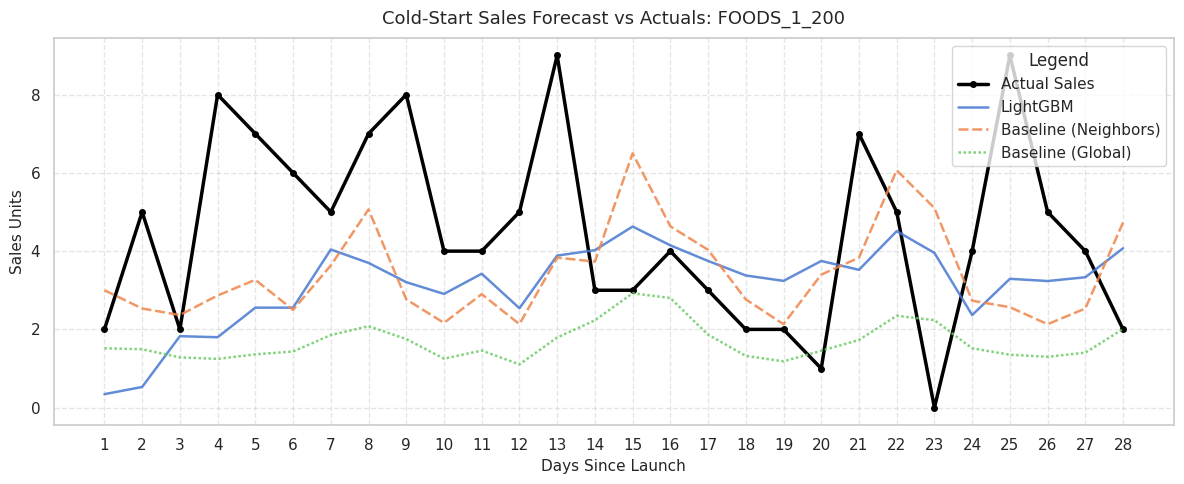

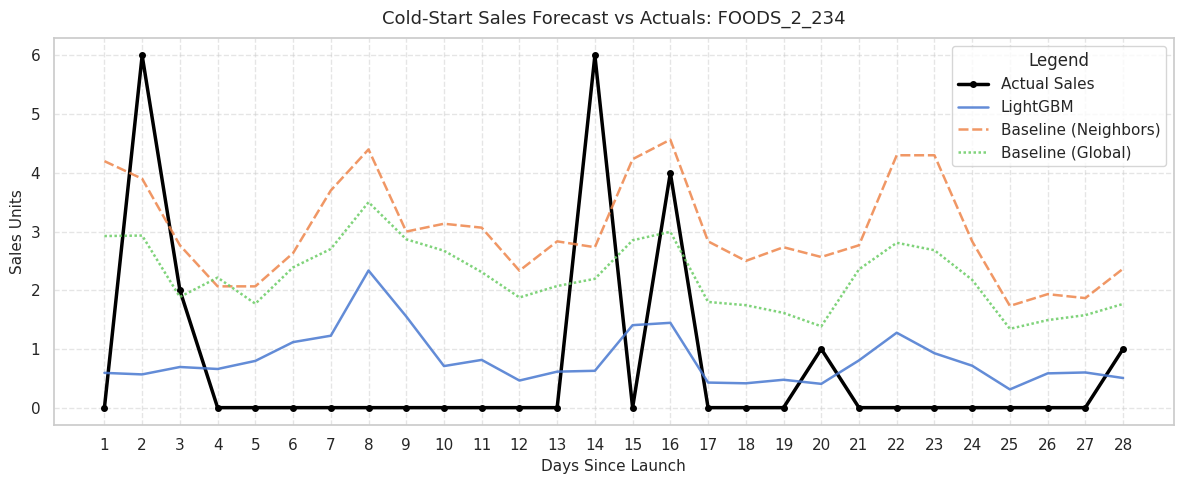

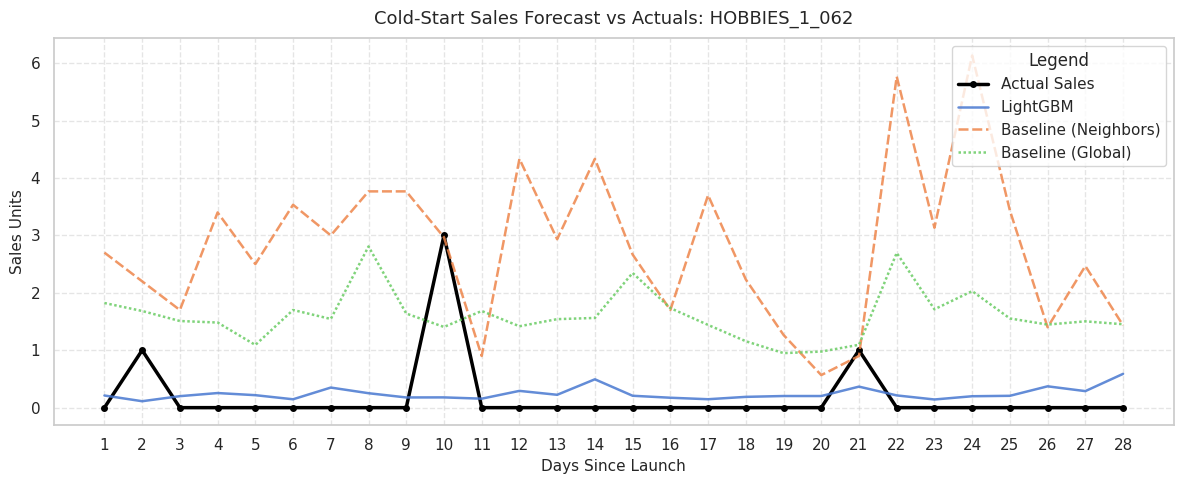

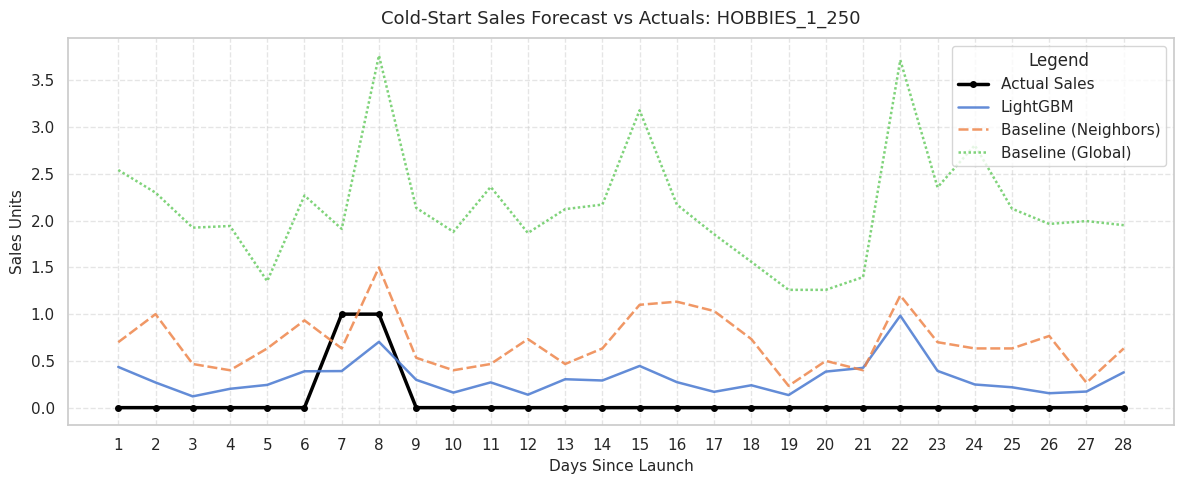

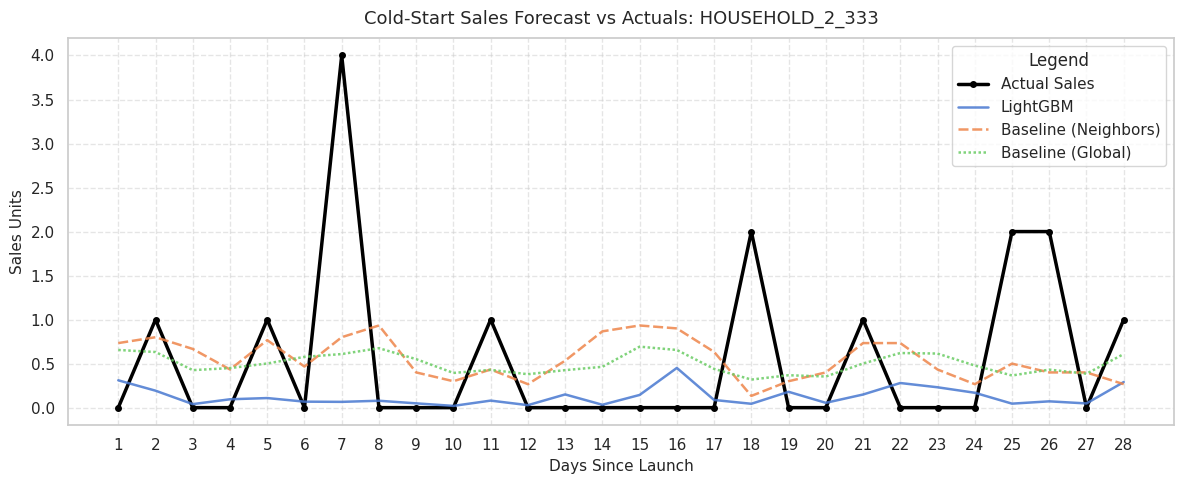

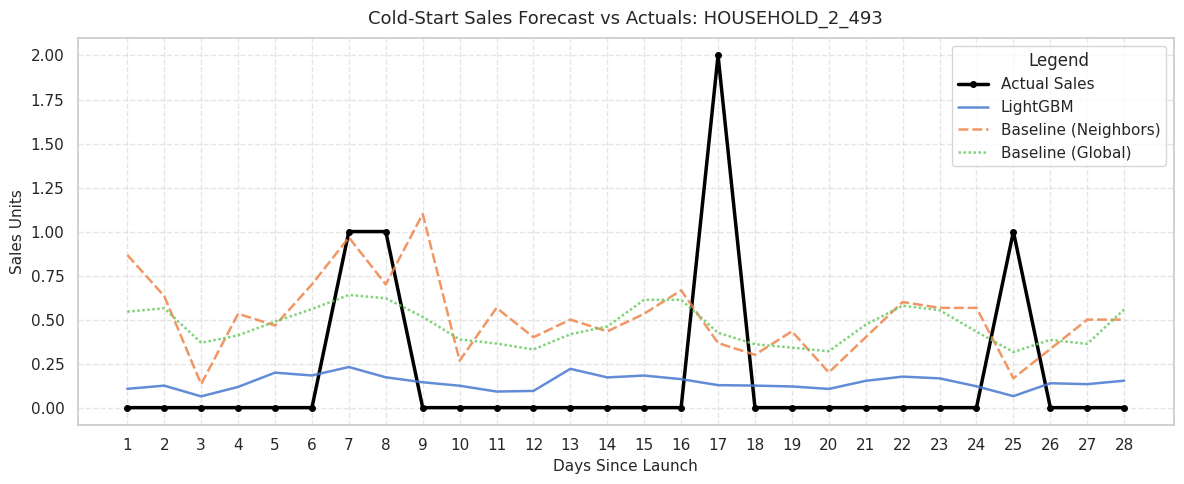

In [45]:
plot_actual_vs_preds(df_all_preds=preds,filename=BASE_DIR/'case_studies/cold_start_preds_all_items.png')

In [18]:
"""
Item-Level Inventory Cost Breakdown Audit
Author: Coding Partner
Goal: Dissect total inventory cost into holding cost vs stockout cost components per item.
"""

import numpy as np
import pandas as pd


def audit_cost_per_item(
    df_test: pd.DataFrame, preds: pd.DataFrame
) -> pd.DataFrame:
    """Calculates holding cost, stockout cost, and total inventory cost per item.

    Parameters:
    -----------
    df_test : pd.DataFrame
        DataFrame containing ground truth ['item_id', 'date', 'sell_price', 'sales'].
    preds : pd.DataFrame
        DataFrame containing ['item_id', 'date', 'sales_pred', 'q90'].

    Returns:
    --------
    pd.DataFrame with breakdown of unit_price, total_holding_cost,
    total_stockout_cost, and total_cost per item.
    """
    item_data = df_test[["item_id", "date", "sell_price", "sales"]].copy()
    item_data = item_data.merge(preds, on=["item_id", "date"], how="left")

    # Financial Unit Metrics
    item_data["cost"] = 0.60 * item_data["sell_price"]
    item_data["profit"] = 0.40 * item_data["sell_price"]
    item_data["holding_cost_rate"] = (0.25 / 365) * item_data["cost"]

    # 1. Holding Cost on Safety Stock
    # Safety stock buffer = max(0, q90 - sales_pred)
    item_data["safety_stock"] = (
        item_data["q90"] - item_data["sales_pred"]
    ).clip(lower=0)
    item_data["cost_holding"] = (
        item_data["holding_cost_rate"] * item_data["safety_stock"]
    )

    # 2. Stockout Cost on Shortages
    # Expected shortage = max(0, sales - q90)
    item_data["expected_shortage"] = (
        item_data["sales"] - item_data["q90"]
    ).clip(lower=0)
    item_data["cost_stockout"] = (
        item_data["profit"] * item_data["expected_shortage"]
    )

    # 3. Aggregate Metrics per Item
    summary = (
        item_data.groupby("item_id")
        .agg(
            avg_sell_price=("sell_price", "mean"),
            holding_cost_total=("cost_holding", "sum"),
            stockout_cost_total=("cost_stockout", "sum"),
            total_cost=("cost_holding", lambda x: x.sum() + item_data.loc[x.index, "cost_stockout"].sum()),
        )
        .reset_index()
    )

    # Correct total cost calculation per group
    summary["total_cost"] = (
        summary["holding_cost_total"] + summary["stockout_cost_total"]
    )

    return summary

In [26]:


def compute_fva(df_metrics: pd.DataFrame, baseline_name: str = "Global_Dept_baseline"):
    """Calculates Forecast Value Added (FVA %) for MAE, Bias, and Total Cost

    relative to a specified baseline model.
    """
    df_fva = df_metrics.copy()

    # Pivot table to align model metrics side-by-side per item
    pivot_mae = df_fva.pivot(index="item_id", columns="model", values="mae")
    pivot_cost_90 = df_fva.pivot(
        index="item_id", columns="model", values="cost_90"
    )
    pivot_cost_95 = df_fva.pivot(
        index="item_id", columns="model", values="cost_95"
    )
    pivot_cost_97 = df_fva.pivot(
        index="item_id", columns="model", values="cost_97"
    )
    # Compute FVA % relative to baseline
    fva_rows = []
    for item_id in df_fva["item_id"].unique():
        base_mae = pivot_mae.loc[item_id, baseline_name]
        base_cost = pivot_cost_90.loc[item_id, baseline_name]

        for model in df_fva[df_fva["item_id"] == item_id]["model"]:
            m_mae = pivot_mae.loc[item_id, model]
            m_cost_90 = pivot_cost_90.loc[item_id, model]
            m_cost_95 = pivot_cost_95.loc[item_id,model]
            m_cost_97 = pivot_cost_97.loc[item_id,model]
            # FVA Formula: (Baseline - Model) / Baseline * 100
            fva_mae = (
                ((base_mae - m_mae) / base_mae * 100) if base_mae != 0 else 0
            )
            fva_cost_90 = (
                ((base_cost - m_cost_90) / base_cost * 100) if base_cost != 0 else 0
            )
            fva_cost_95 = (
                        ((base_cost - m_cost_95) / base_cost * 100) if base_cost != 0 else 0
                    )
            fva_cost_97 = (
                        ((base_cost - m_cost_97) / base_cost * 100) if base_cost != 0 else 0
                    )

            fva_rows.append(
                {
                    "item_id": item_id,
                    "model": model,
                    "fva_mae_pct": round(fva_mae, 2),
                    "fva_cost_pct": round(fva_cost_90, 2),
                    "fva_cost_95" : round(fva_cost_95,2),
                    "fva_cost_97" : round(fva_cost_97)
                }
            )

    df_fva_results = pd.DataFrame(fva_rows)

    # Merge FVA metrics back into the master metrics table
    return pd.merge(df_fva, df_fva_results, on=["item_id", "model"])

fva_comparison = compute_fva(df_metrics=metrics)

In [27]:
fva_comparison

,item_id,model,bias_pct,cost_90,cost_95,cost_97,mae,fva_mae_pct,fva_cost_pct,fva_cost_95,fva_cost_97
0,FOODS_1_200,Global_Dept_baseline,-0.624454,7.802648,4.770229,3.098624,3.756123,0.00,0.00,38.86,60
1,FOODS_1_200,Nbr_Dept_baseline,-0.238624,0.732151,0.121487,0.107094,2.993233,20.31,90.62,98.44,99
2,FOODS_1_200,lgb,-0.297484,0.869725,0.060368,0.063546,2.974312,20.81,88.85,99.23,99
3,FOODS_2_234,Global_Dept_baseline,2.145763,0.212236,0.258531,0.288597,2.275377,0.00,0.00,-21.81,-36
4,FOODS_2_234,Nbr_Dept_baseline,3.218333,0.188485,0.221126,0.242324,2.870616,-26.16,11.19,-4.19,-14
5,FOODS_2_234,lgb,0.152915,1.486045,0.203356,1.705078,1.772941,22.08,-600.19,4.18,-703
6,HOBBIES_1_062,Global_Dept_baseline,7.996450,0.083125,0.102171,0.114541,1.631015,0.00,0.00,-22.91,-38
7,HOBBIES_1_062,Nbr_Dept_baseline,14.766667,0.106518,0.128371,0.142562,3.044035,-86.63,-28.14,-54.43,-72
8,HOBBIES_1_062,lgb,0.351001,0.418742,0.169120,0.064090,0.624356,61.72,-403.75,-103.45,23
9,HOBBIES_1_250,Global_Dept_baseline,29.077093,0.516365,0.629699,0.703302,2.157584,0.00,0.00,-21.95,-36


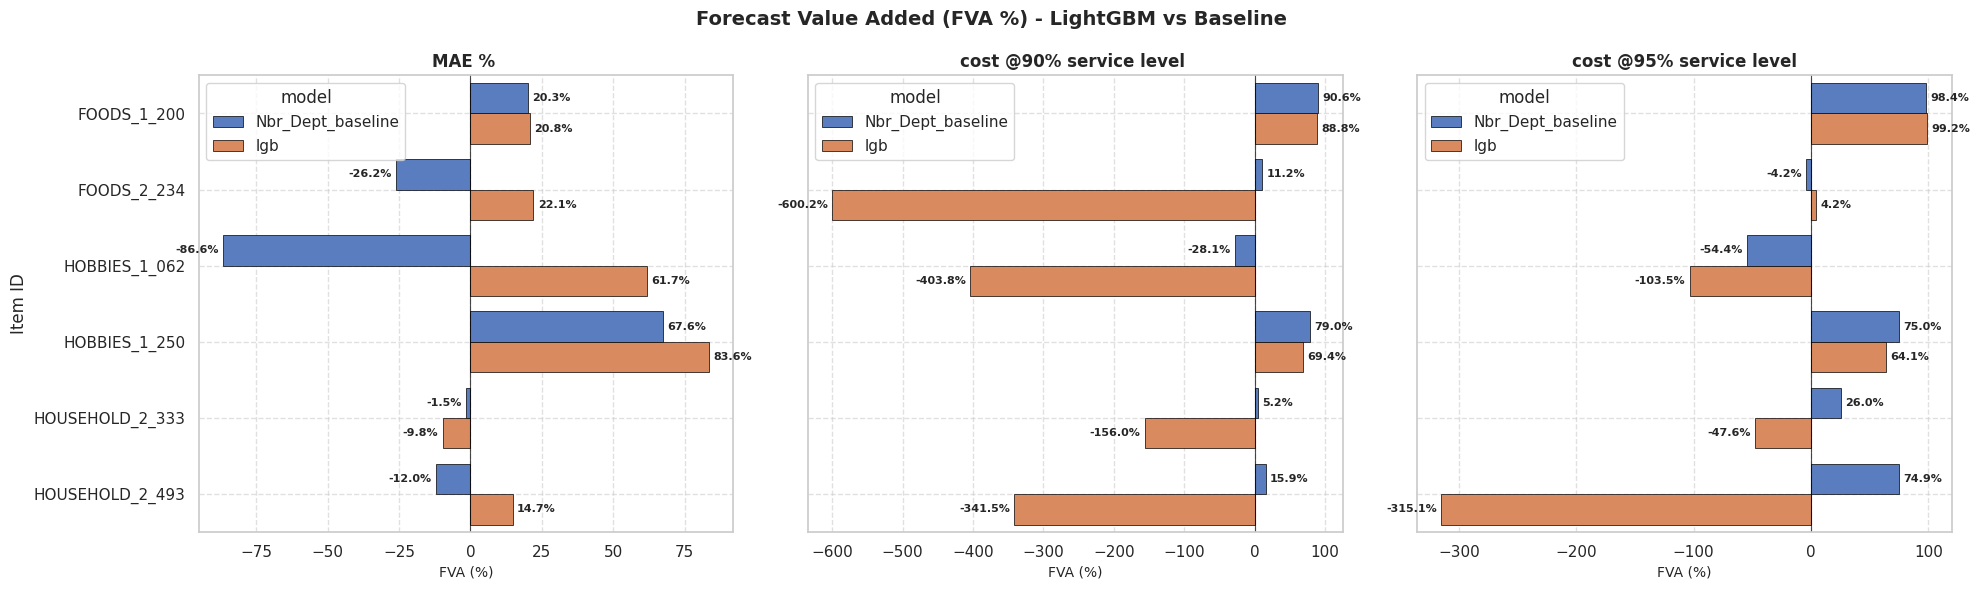

In [44]:


sns.set_theme(style="whitegrid", palette="muted")


def plot_fva_metrics(df: pd.DataFrame, title_prefix: str = "LightGBM vs Baseline"):
    """Generates comparative horizontal bar plots for Forecast Value Added (FVA %)

    for MAE and Cost against the Global Dept Baseline.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns ['item_id', 'model', 'fva_mae_pct', 'fva_cost_pct'].
    title_prefix : str, optional
        Prefix string for the overall figure title.
    """
    # Filter out baseline since FVA % is 0.0 for baseline models
    plot_df = df[df["model"] != "Global_Dept_baseline"].copy()

    # Setup 1x2 subplots figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

    if title_prefix:
        fig.suptitle(
            f"Forecast Value Added (FVA %) - {title_prefix}",
            fontsize=14,
            fontweight="bold",
            y=0.98
            ,
        )

    # Metric column configurations: (column_name, plot_title, label_format)
    metrics_config = [
        ("fva_mae_pct", "MAE % ", "{:.1f}%"),
        ("fva_cost_pct", "cost @90% service level ", "{:.1f}%"),
        ("fva_cost_95", "cost @95% service level", "{:.1f}%"),
        ("fva_cost_97", "cost @97% service level ", "{:.1f}%"),
    ]

    for ax, (metric_col, title, fmt) in zip(axes, metrics_config):
        sns.barplot(
            data=plot_df,
            y="item_id",
            x=metric_col,
            hue="model",
            ax=ax,
            edgecolor="black",
            linewidth=0.5,
        )

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("FVA (%)", fontsize=10)
        ax.set_ylabel("Item ID" if ax == axes[0] else "")
        ax.grid(True, linestyle="--", alpha=0.6)

        # Draw a reference line at 0% baseline
        ax.axvline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.7)

        # Annotate numeric bar values directly
        for container in ax.containers:
            ax.bar_label(
                container,
                fmt=fmt,
                padding=3,
                fontsize=8,
                fontweight="bold",
            )

    plt.tight_layout()
    plt.savefig(f'{BASE_DIR}/case_studies/fva_cold_start.png')
    plt.show()


# Example usage:
plot_fva_metrics(fva_comparison, title_prefix="LightGBM vs Baseline")